In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import blimpy as bl 
import glob
import os
import psutil
%matplotlib inline

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

In [2]:
df0 = pd.read_csv('/datax/scratch/benjb/bl_nearby_stars/BL_cadences_unique_nearby_star_sample_only.csv')
df0

,Target,RA,DEC,Distance (pc),Cadence ID,Cadence Type,Receiver,Vmag,Spectral Type,.h5 path 1,...,.h5 path 3,.h5 path 4,.h5 path 5,.h5 path 6,.dat path 1,.dat path 2,.dat path 3,.dat path 4,.dat path 5,.dat path 6
0,GJ1002,0 6 42.9,-7 32 51,4.69,3635,ABACAD,Rcvr1_2,13.7,M5.0V,/datag/pipeline/AGBT16A_999_219/holding/splice...,...,/datag/pipeline/AGBT16A_999_219/holding/splice...,/datag/pipeline/AGBT16A_999_219/holding/splice...,/datag/pipeline/AGBT16A_999_219/holding/splice...,/datag/pipeline/AGBT16A_999_219/holding/splice...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...
1,GJ1002,0 6 42.9,-7 32 51,4.69,9642,ABACAD,Rcvr2_3,13.7,M5.0V,/datag/pipeline/AGBT16B_999_18/holding/spliced...,...,/datag/pipeline/AGBT16B_999_18/holding/spliced...,/datag/pipeline/AGBT16B_999_18/holding/spliced...,/datag/pipeline/AGBT16B_999_18/holding/spliced...,/datag/pipeline/AGBT16B_999_18/holding/spliced...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...
2,GJ1002,0 6 42.9,-7 32 51,4.69,12847,ABACAD,Rcvr4_6,13.7,M5.0V,/datag/pipeline/AGBT16B_999_82/collate/spliced...,...,/datag/pipeline/AGBT16B_999_82/collate/spliced...,/datag/pipeline/AGBT16B_999_82/collate/spliced...,/datag/pipeline/AGBT16B_999_82/collate/spliced...,/datag/pipeline/AGBT16B_999_82/collate/spliced...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...
3,GJ1002,0 6 42.9,-7 32 51,4.69,423617,ABACAD,Rcvr4_6,13.7,M5.0V,/datag/pipeline/AGBT23B_999_31/blc01_blp01/blc...,...,/datag/pipeline/AGBT23B_999_31/blc01_blp01/blc...,/datag/pipeline/AGBT23B_999_31/blc01_blp01/blc...,/datag/pipeline/AGBT23B_999_31/blc01_blp01/blc...,/datag/pipeline/AGBT23B_999_31/blc01_blp01/blc...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...
4,GJ1002,0 6 42.9,-7 32 51,4.69,423617,ABACAD,Rcvr4_6,13.7,M5.0V,/datag/pipeline/AGBT23B_999_31/blc02_blp02/blc...,...,/datag/pipeline/AGBT23B_999_31/blc02_blp02/blc...,/datag/pipeline/AGBT23B_999_31/blc02_blp02/blc...,/datag/pipeline/AGBT23B_999_31/blc02_blp02/blc...,/datag/pipeline/AGBT23B_999_31/blc02_blp02/blc...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39172,SO0253,2 53 4.68,16 51 52,3.85,421558,ABACAD,Rcvr8_10_NEW,15.1,M6.5V,/datag/pipeline/AGBT23B_999_14/blc72_blp32/blc...,...,/datag/pipeline/AGBT23B_999_14/blc72_blp32/blc...,/datag/pipeline/AGBT23B_999_14/blc72_blp32/blc...,/datag/pipeline/AGBT23B_999_14/blc72_blp32/blc...,/datag/pipeline/AGBT23B_999_14/blc72_blp32/blc...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_

In [3]:
bliss_dats = np.concatenate([
    glob.glob('/datax/scratch/benjb/bl_nearby_stars/bliss_dats_pooled_090825/*.dat'),
    glob.glob('/datax/scratch/benjb/bl_nearby_stars/bliss_dats_pooled_090825/*.dat')
])
lfvec = []
ldvec = []
lsvec = []
sfvec = []
sdvec = []
ssvec = []
cfvec = []
cdvec = []
csvec = []
xfvec = []
xdvec = []
xsvec = []
xfvec_new = []
xdvec_new = []
xsvec_new = []

In [ ]:
dats = np.concatenate(
    (df0['.dat path 1'].values,
    df0['.dat path 2'].values,
    df0['.dat path 3'].values,
    df0['.dat path 4'].values,
    df0['.dat path 5'].values,
    df0['.dat path 6'].values)
)
print(len(dats))
udats = np.unique(dats)
print(len(udats))
lfvec = []
ldvec = []
lsvec = []
sfvec = []
sdvec = []
ssvec = []
cfvec = []
cdvec = []
csvec = []
xfvec = []
xdvec = []
xsvec = []
xfvec_new = []
xdvec_new = []
xsvec_new = []

235062
231493


In [4]:
fvec = []
dvec = []
svec = []
wvec = []

for iii, dat in enumerate(bliss_dats):
    if iii % 1000 == 0:
        print(iii, 'out of', len(bliss_dats))
    df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
    f = df['freq_start'].values
    d = df['Drift_Rate'].values
    s = df['SNR'].values
    w = df['Full_number_of_hits'].values
    fvec.append(f)
    dvec.append(d)
    svec.append(s)
    wvec.append(w)
fvec = np.concatenate(fvec)
dvec = np.concatenate(dvec)
svec = np.concatenate(svec)
wvec = np.concatenate(wvec)
print(len(wvec))

# PICK UP HERE 092425

0 out of 369876
1000 out of 369876
2000 out of 369876
3000 out of 369876
4000 out of 369876
5000 out of 369876
6000 out of 369876
7000 out of 369876
8000 out of 369876
9000 out of 369876
10000 out of 369876
11000 out of 369876
12000 out of 369876
13000 out of 369876
14000 out of 369876
15000 out of 369876
16000 out of 369876
17000 out of 369876
18000 out of 369876
19000 out of 369876
20000 out of 369876
21000 out of 369876
22000 out of 369876
23000 out of 369876
24000 out of 369876
25000 out of 369876
26000 out of 369876
27000 out of 369876
28000 out of 369876
29000 out of 369876
30000 out of 369876
31000 out of 369876
32000 out of 369876
33000 out of 369876
34000 out of 369876
35000 out of 369876
36000 out of 369876
37000 out of 369876
38000 out of 369876
39000 out of 369876
40000 out of 369876
41000 out of 369876
42000 out of 369876
43000 out of 369876
44000 out of 369876
45000 out of 369876
46000 out of 369876
47000 out of 369876
48000 out of 369876
49000 out of 369876
50000 out of 

In [5]:
plt.scatter(fvec, svec)
plt.yscale('log')
plt.show()

KeyboardInterrupt: 

In [ ]:
for iii, dat in enumerate(udats):
    #print(dat)

    if iii % 1000 == 0:
        print(iii, 'out of', len(udats))

    if dat == 'None':
        continue

    if psutil.virtual_memory()[1] < 32e9:
        print('Tried to read too much into memory!')
        break

    argwhere = np.where(
        (df0['.dat path 1'].values == dat) | (df0['.dat path 2'].values == dat) | (df0['.dat path 3'].values == dat) |
        (df0['.dat path 4'].values == dat) | (df0['.dat path 5'].values == dat) | (df0['.dat path 6'].values == dat)
        )[0]
    receiver = df0['Receiver'].values[argwhere][0]
    cadence = df0['Cadence ID'].values[argwhere][0]

    df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
    if receiver == 'Rcvr1_2':
        tdf = df.iloc[
            np.where((df['Uncorrected_Frequency'].values > 1100) & (df['Uncorrected_Frequency'].values < 1200) |
                    (df['Uncorrected_Frequency'].values > 1340) & (df['Uncorrected_Frequency'].values < 1900))[0]
            ]
        f = tdf['freq_start'].values
        d = tdf['Drift_Rate'].values
        s = tdf['SNR'].values
        lfvec.append(f)
        ldvec.append(d)
        lsvec.append(s)
    elif receiver == 'Rcvr2_3':
        tdf = df.iloc[
            np.where((df['Uncorrected_Frequency'].values > 1800) & (df['Uncorrected_Frequency'].values < 2300) |
                    (df['Uncorrected_Frequency'].values > 2360) & (df['Uncorrected_Frequency'].values < 2700))[0]
            ]
        f = tdf['freq_start'].values
        d = tdf['Drift_Rate'].values
        s = tdf['SNR'].values
        sfvec.append(f)
        sdvec.append(d)
        ssvec.append(s)
    elif receiver == 'Rcvr4_6':
        tdf = df.iloc[
            np.where((df['Uncorrected_Frequency'].values > 4000) & (df['Uncorrected_Frequency'].values < 7800))[0]
            ]
        f = tdf['freq_start'].values
        d = tdf['Drift_Rate'].values
        s = tdf['SNR'].values
        cfvec.append(f)
        cdvec.append(d)
        csvec.append(s)
    elif receiver == 'Rcvr8_10':
        tdf = df.iloc[
            np.where((df['Uncorrected_Frequency'].values > 7800) & (df['Uncorrected_Frequency'].values < 11200))[0]
            ]
        f = tdf['freq_start'].values
        d = tdf['Drift_Rate'].values
        s = tdf['SNR'].values
        xfvec.append(f)
        xdvec.append(d)
        xsvec.append(s)
    elif receiver == 'Rcvr8_10_NEW':
        tdf = df.iloc[
            np.where((df['Uncorrected_Frequency'].values > 7550) & (df['Uncorrected_Frequency'].values < 11700))[0]
            ]
        f = tdf['freq_start'].values
        d = tdf['Drift_Rate'].values
        s = tdf['SNR'].values
        xfvec_new.append(f)
        xdvec_new.append(d)
        xsvec_new.append(s)
    #fb = bl.Waterfall(h5_path, load_data=False)
    #ghz = fb.header['nchans']*2.7939677238464355e-06/1e3
    #semester_counts.append([semester, receiver, len(f), ghz])

lfvec = np.concatenate(lfvec)
ldvec = np.concatenate(ldvec)
lsvec = np.concatenate(lsvec)
sfvec = np.concatenate(sfvec)
sdvec = np.concatenate(sdvec)
ssvec = np.concatenate(ssvec)
cfvec = np.concatenate(cfvec)
cdvec = np.concatenate(cdvec)
csvec = np.concatenate(csvec)
xfvec = np.concatenate(xfvec)
xdvec = np.concatenate(xdvec)
xsvec = np.concatenate(xsvec)
xfvec_new = np.concatenate(xfvec_new)
xdvec_new = np.concatenate(xdvec_new)
xsvec_new = np.concatenate(xsvec_new)

print(len(lfvec))
print(len(sfvec))
print(len(cfvec))
print(len(xfvec))
print(len(xfvec_new))

0 out of 231493
1000 out of 231493
2000 out of 231493
3000 out of 231493
4000 out of 231493
5000 out of 231493
6000 out of 231493
7000 out of 231493
8000 out of 231493
9000 out of 231493
10000 out of 231493
11000 out of 231493
12000 out of 231493
13000 out of 231493
14000 out of 231493
15000 out of 231493
16000 out of 231493
17000 out of 231493
18000 out of 231493
19000 out of 231493
20000 out of 231493
21000 out of 231493
22000 out of 231493
23000 out of 231493
24000 out of 231493
25000 out of 231493
26000 out of 231493
27000 out of 231493
28000 out of 231493
29000 out of 231493
30000 out of 231493
31000 out of 231493
32000 out of 231493
33000 out of 231493
34000 out of 231493
35000 out of 231493
36000 out of 231493
37000 out of 231493
38000 out of 231493
39000 out of 231493
40000 out of 231493
41000 out of 231493
42000 out of 231493
43000 out of 231493
44000 out of 231493
45000 out of 231493
46000 out of 231493
47000 out of 231493
48000 out of 231493
49000 out of 231493
50000 out of 

In [5]:
dfa = pd.read_csv('/datax/scratch/benjb/bl_nearby_stars/seticore_output/findevent/all_events.csv')
dfa

,Unnamed: 0,Cadence Index,Source,Frequency,Drift Rate,SNR
0,0,0.0,GJ1002,1599.453400,-0.756713,21.043835
1,1,10007.0,HIP20219,1557.382747,-0.010204,23.126204
2,2,10011.0,HIP20261,2107.503989,-0.081634,27.665854
3,3,10011.0,HIP20261,2107.323474,-0.081634,45.568272
4,4,10011.0,HIP20261,2107.158001,-0.081634,42.477215
...,...,...,...,...,...,...
77380,77380,9927.0,HIP19990,4089.615585,-0.010204,15.930622
77381,77381,9931.0,HIP2,1620.175648,-3.642919,11.344711
77382,77382,9940.0,HIP2,2196.310680,0.010204,14.883245
77383,77383,9940.0,HIP2,2195.775255,0.010204,102.725464


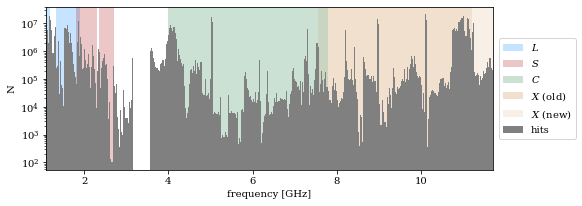

In [8]:
#fvec = np.concatenate((lfvec, sfvec, cfvec, xfvec, xfvec_new))
#event_fvec = dfa['Frequency'].values

fig = plt.subplots(1, 1, figsize=(8,3))

plt.axvspan(1.1, 1.9, color='dodgerblue', alpha=0.25, lw=0, label=r'$L$')
plt.axvspan(1.8, 2.7, color='firebrick', alpha=0.25, lw=0, label=r'$S$')
plt.axvspan(4.0, 7.8, color='seagreen', alpha=0.25, lw=0, label=r'$C$')
plt.axvspan(7.8, 11.2, color='peru', alpha=0.25, lw=0, label=r'$X$ (old)')
plt.axvspan(7.55, 7.8, color='peru', alpha=0.125, lw=0, label=r'$X$ (new)')
plt.axvspan(11.2, 11.7, color='peru', alpha=0.125, lw=0)
plt.axvspan(1.2, 1.34, color='white', lw=0, alpha=1)
plt.axvspan(2.3, 2.36, color='white', lw=0, alpha=1)

plt.hist(fvec/1000, bins=500, range=(1.1, 11.7), color='gray', label='hits')
#plt.hist(event_fvec/1000, bins=500, range=(1.1, 11.7), color='steelblue', label='events')

plt.xlabel('frequency [GHz]')
plt.ylabel('N')
plt.yscale('log')
plt.xlim(1.1,11.7)
plt.legend(loc='center', bbox_to_anchor=(1.1, 0.5))
plt.savefig('/datax/scratch/benjb/bl_nearby_stars/full_hit_event_frequency_histogram_BLISS_example_092425.pdf', bbox_inches='tight')

plt.show()

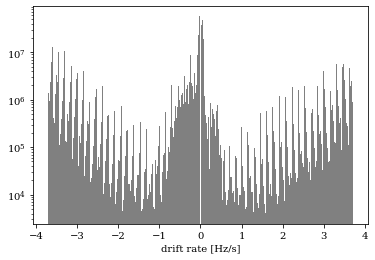

In [10]:
plt.hist(dvec, bins=500, color='gray')
plt.xlabel('drift rate [Hz/s]')
plt.yscale('log')
plt.show()

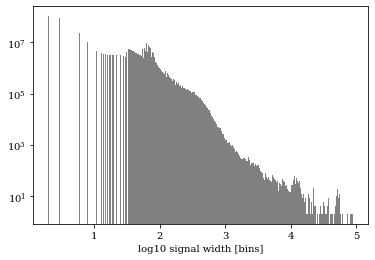

In [18]:
plt.hist(np.log10(wvec.astype(float)), bins=500, color='gray')
plt.xlabel('log10 signal width [bins]')
plt.yscale('log')
plt.show()

In [16]:
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_lfvec.pdf', lfvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_ldvec.pdf', ldvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_lsvec.pdf', lsvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_sfvec.pdf', sfvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_sdvec.pdf', sdvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_ssvec.pdf', ssvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_cfvec.pdf', cfvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_cdvec.pdf', cdvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_csvec.pdf', csvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_xfvec.pdf', xfvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_xdvec.pdf', xdvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_xsvec.pdf', xsvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_xfvec_new.pdf', xfvec_new)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_xdvec_new.pdf', xdvec_new)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_xsvec_new.pdf', xsvec_new)

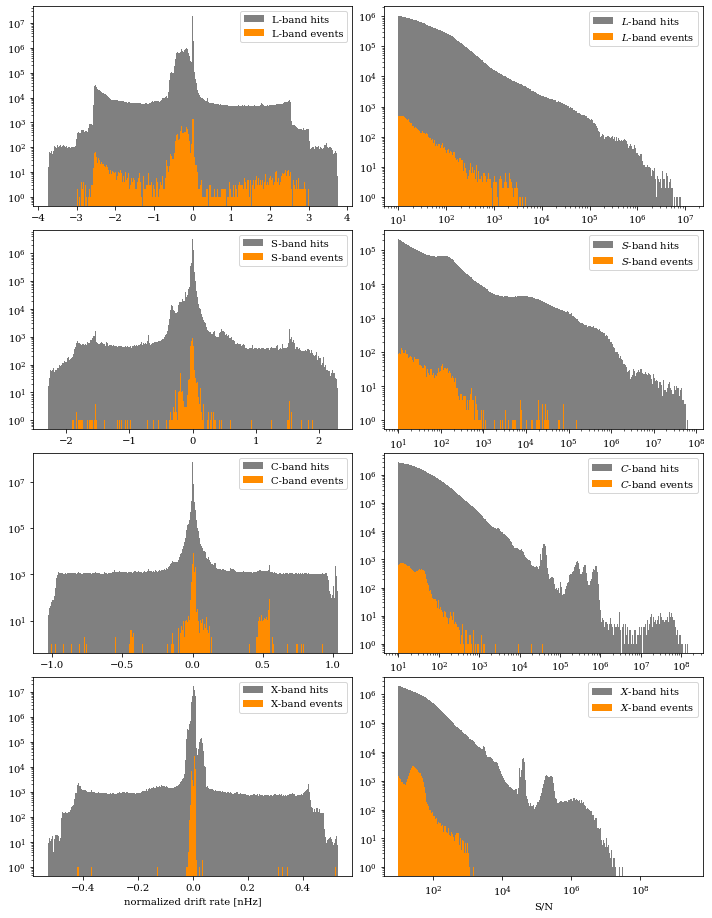

In [ ]:
fig, ax = plt.subplots(4, 2, figsize=(12,16))
hit_color = 'gray'
event_color = 'darkorange'
nbins = 300

event_f = dfa['Frequency'].values/1000
event_d = dfa['Drift Rate'].values
event_s = dfa['SNR'].values
event_fvec_L = event_f[np.where(event_f < 1.9)[0]]
event_fvec_S = event_f[np.where((event_f > 1.9) & (event_f < 2.7))[0]]
event_fvec_C = event_f[np.where((event_f > 4) & (event_f < 7.8))[0]]
event_fvec_X = event_f[np.where(event_f > 7.8)[0]]
event_dvec_L = event_d[np.where(event_f < 1.9)[0]]
event_dvec_S = event_d[np.where((event_f > 1.9) & (event_f < 2.7))[0]]
event_dvec_C = event_d[np.where((event_f > 4) & (event_f < 7.8))[0]]
event_dvec_X = event_d[np.where(event_f > 7.8)[0]]
event_svec_L = event_s[np.where(event_f < 1.9)[0]]
event_svec_S = event_s[np.where((event_f > 1.9) & (event_f < 2.7))[0]]
event_svec_C = event_s[np.where((event_f > 4) & (event_f < 7.8))[0]]
event_svec_X = event_s[np.where(event_f > 7.8)[0]]

ax[0,0].hist(ldvec/(lfvec/1000), color=hit_color, bins=nbins, label='L-band hits')
ax[1,0].hist(sdvec/(sfvec/1000), color=hit_color, bins=nbins, label='S-band hits')
ax[2,0].hist(cdvec/(cfvec/1000), color=hit_color, bins=nbins, label='C-band hits')
ax[3,0].hist(xdvec/(xfvec/1000), color=hit_color, bins=nbins, label='X-band hits')
ax[0,0].hist(event_dvec_L/(event_fvec_L), color=event_color, bins=nbins, range=(np.min(ldvec/(lfvec/1000)), np.max(ldvec/(lfvec/1000))),
             label=r'$L$-band events')
ax[1,0].hist(event_dvec_S/(event_fvec_S), color=event_color, bins=nbins, range=(np.min(sdvec/(sfvec/1000)), np.max(sdvec/(sfvec/1000))),
             label=r'$S$-band events')
ax[2,0].hist(event_dvec_C/(event_fvec_C), color=event_color, bins=nbins, range=(np.min(cdvec/(cfvec/1000)), np.max(cdvec/(cfvec/1000))),
             label=r'$C$-band events')
ax[3,0].hist(event_dvec_X/(event_fvec_X), color=event_color, bins=nbins, range=(np.min(xdvec/(xfvec/1000)), np.max(xdvec/(xfvec/1000))),
             label=r'$X$-band events')

hist, bins = np.histogram(lsvec, bins=nbins, range=(np.min(lsvec), np.max(lsvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[0,1].hist(lsvec, color=hit_color, bins=logbins, label=r'$L$-band hits')
hist, bins = np.histogram(event_svec_L, bins=nbins, range=(np.min(lsvec), np.max(lsvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[0,1].hist(event_svec_L, color=event_color, bins=logbins, label=r'$L$-band events')
ax[0,1].set_xscale('log')

hist, bins = np.histogram(ssvec, bins=nbins, range=(np.min(ssvec), np.max(ssvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[1,1].hist(ssvec, color=hit_color, bins=logbins, label=r'$S$-band hits')
hist, bins = np.histogram(event_svec_S, bins=nbins, range=(np.min(ssvec), np.max(ssvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[1,1].hist(event_svec_S, color=event_color, bins=logbins, label=r'$S$-band events')
ax[1,1].set_xscale('log')

hist, bins = np.histogram(csvec, bins=nbins, range=(np.min(csvec), np.max(csvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[2,1].hist(csvec, color=hit_color, bins=logbins, label=r'$C$-band hits')
hist, bins = np.histogram(event_svec_C, bins=nbins, range=(np.min(csvec), np.max(csvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[2,1].hist(event_svec_C, color=event_color, bins=logbins, label=r'$C$-band events')
ax[2,1].set_xscale('log')

hist, bins = np.histogram(xsvec, bins=nbins, range=(np.min(xsvec), np.max(xsvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[3,1].hist(xsvec, color=hit_color, bins=logbins, label=r'$X$-band hits')
hist, bins = np.histogram(event_svec_X, bins=nbins, range=(np.min(xsvec), np.max(xsvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[3,1].hist(event_svec_X, color=event_color, bins=logbins, label=r'$X$-band events')
ax[3,1].set_xscale('log')


for a in ax.flat:
    a.set_yscale('log')
    a.legend()
ax[3,0].set_xlabel('normalized drift rate [nHz]')
ax[3,1].set_xlabel('S/N')
plt.subplots_adjust(wspace=0.1, hspace=0.12)

plt.savefig('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_drift_and_SNR_histograms.pdf', bbox_inches='tight')
plt.show()